# BIST KAP Bildirimleri — Sentiment Analizi

**Amaç:** `savasy/bert-base-turkish-sentiment-cased` ile skorlanmış KAP bildirimlerini event study sonuçlarıyla birleştirip, sentiment'in fiyat tepkisini öngörüp öngörmediğini test etmek.

**Veri:** `data/processed/sentiment.parquet` (232 bildirim, binary positive/negative + skor 0..1). Skorlama scripti: `scripts/score_sentiment.py`.

**Anahtar hipotez:** Event study'de bulunan **"ertesi-gün bar map"** pozitif CAR sinyali, **sentiment-pozitif** bildirimlerde daha güçlü olmalı. 2×2 ızgara: sentiment × timing → CAR.


In [1]:
from __future__ import annotations
import sys
from pathlib import Path

_here = Path.cwd()
_project_root = _here if (_here / "src").exists() else _here.parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.config import TICKERS, PROCESSED_DIR
from src.analysis.loaders import load_all_prices, load_all_disclosures
from src.analysis.event_study import run_event_study_multi

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.precision", 4)
print(f"Hisseler: {list(TICKERS)}")


Hisseler: ['THYAO', 'ASELS', 'GARAN', 'KCHOL', 'EREGL']


## 1. Veri Yükleme — Sentiment + Event Study

`sentiment.parquet`'i okuyup `(ticker, disclosure_index)` üzerinden event study sonuçlarına join ediyoruz. Event study aynı parametrelerle yeniden çalıştırılıyor (`before=1, after=3, est=60`).

In [2]:
# Sentiment skorlari
sentiment = pd.read_parquet(PROCESSED_DIR / "sentiment.parquet")
print(f"Sentiment: {len(sentiment)} satir, kolonlar: {list(sentiment.columns)}")
print()
print("Label dagilim:")
print(sentiment["sentiment_label"].value_counts().to_string())


Sentiment: 232 satir, kolonlar: ['ticker', 'disclosure_index', 'publish_datetime', 'subject', 'summary', 'sentiment_label', 'sentiment_score']

Label dagilim:
sentiment_label
positive    117
negative    115


In [3]:
# Event study'yi yeniden cikar
prices = load_all_prices()
news = load_all_disclosures()
results = run_event_study_multi(prices, news, before=1, after=3, estimation_window=60)
ok = results[results["status"] == "ok"].copy()
print(f"OK olay: {len(ok)} / toplam {len(results)}")


OK olay: 221 / toplam 232


In [4]:
# Sentiment ile event study'yi birlestir
# event_idx -> news[event_idx]['disclosure_index'] zaten loaders'da ayni siradan turetiliyor
# Ama daha guvenli: news'ten disclosure_index'i alip event_idx ile eslestir
news_with_idx = news.reset_index().rename(columns={"index": "event_idx"})
ok = ok.merge(
    news_with_idx[["event_idx", "disclosure_index", "ticker", "subject", "summary"]],
    on=["event_idx", "ticker"], how="left", validate="one_to_one",
)

# Sentiment join
df = ok.merge(
    sentiment[["ticker", "disclosure_index", "sentiment_label", "sentiment_score"]],
    on=["ticker", "disclosure_index"], how="left", validate="one_to_one",
)

# Timing (ayni-gun vs ertesi-gun) — event_study notebook'undaki ile ayni
df["event_date"] = pd.to_datetime(df["event_time"]).dt.date
df["mapped_date"] = pd.to_datetime(df["mapped_bar"]).dt.date
df["timing"] = np.where(df["event_date"] == df["mapped_date"], "ayni-gun", "ertesi-gun")

print(f"Join sonrasi: {len(df)} satir")
print(f"Sentiment label NaN: {df['sentiment_label'].isna().sum()}")
print()
print("Cross-tab sentiment x timing:")
print(pd.crosstab(df["sentiment_label"], df["timing"]))


Join sonrasi: 221 satir
Sentiment label NaN: 0

Cross-tab sentiment x timing:
timing           ayni-gun  ertesi-gun
sentiment_label                      
negative               75          37
positive               78          31


## 2. Sentiment × CAR — Genel Görünüm

Önce toplu seviyede: sentiment label'a göre CAR ortalama/dağılımı.

In [5]:
print("CAR by sentiment label:")
print(df.groupby("sentiment_label")["car"].describe().round(5))


CAR by sentiment label:
                 count        mean     std     min     25%     50%     75%  \
sentiment_label                                                              
negative         112.0  2.7200e-03  0.0178 -0.0536 -0.0097  0.0029  0.0154   
positive         109.0 -6.0000e-05  0.0191 -0.0630 -0.0129  0.0002  0.0146   

                    max  
sentiment_label          
negative         0.0389  
positive         0.0662  


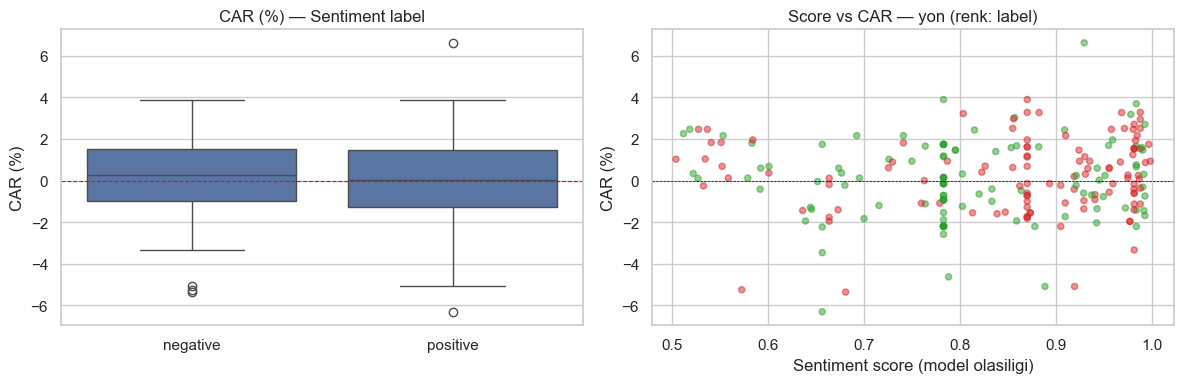

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sol: boxplot CAR by label
sns.boxplot(data=df.assign(car_pct=df["car"] * 100), x="sentiment_label", y="car_pct",
            order=["negative", "positive"], ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0].set_title("CAR (%) — Sentiment label")
axes[0].set_xlabel("")
axes[0].set_ylabel("CAR (%)")

# Sag: scatter score vs CAR
colors = df["sentiment_label"].map({"positive": "tab:green", "negative": "tab:red"})
axes[1].scatter(df["sentiment_score"], df["car"] * 100, c=colors, alpha=0.5, s=20)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.5)
axes[1].set_xlabel("Sentiment score (model olasiligi)")
axes[1].set_ylabel("CAR (%)")
axes[1].set_title("Score vs CAR — yon (renk: label)")

plt.tight_layout()
plt.show()


In [7]:
# t-test: pozitif vs negatif sentiment CAR farki
pos_car = df[df["sentiment_label"] == "positive"]["car"].dropna()
neg_car = df[df["sentiment_label"] == "negative"]["car"].dropna()
welch = stats.ttest_ind(pos_car, neg_car, equal_var=False)
print(f"Pozitif n={len(pos_car)}, ortalama CAR = {pos_car.mean()*100:+.3f}%")
print(f"Negatif n={len(neg_car)}, ortalama CAR = {neg_car.mean()*100:+.3f}%")
print(f"Welch t-test: t={welch.statistic:.3f}, p={welch.pvalue:.4f}")


Pozitif n=109, ortalama CAR = -0.006%
Negatif n=112, ortalama CAR = +0.272%
Welch t-test: t=-1.119, p=0.2643


## 3. ⭐ Sentiment × Timing × CAR — 2×2 Izgara

Anahtar test: event study'deki **ertesi-gün bar map** sinyali sentiment'le birleşince güçleniyor mu?
Beklenti: **pozitif × ertesi-gün** alt-grubu en yüksek pozitif CAR'a sahip olmalı.

In [8]:
grid = df.groupby(["sentiment_label", "timing"])["car"].agg(["count", "mean", "std"])
grid["mean_pct"] = grid["mean"] * 100
grid["std_pct"] = grid["std"] * 100
print("Sentiment x Timing x CAR:")
print(grid[["count", "mean_pct", "std_pct"]].round(3).to_string())


Sentiment x Timing x CAR:
                            count  mean_pct  std_pct
sentiment_label timing                              
negative        ayni-gun       75    -0.054    1.740
                ertesi-gun     37     0.933    1.702
positive        ayni-gun       78    -0.224    1.710
                ertesi-gun     31     0.543    2.278


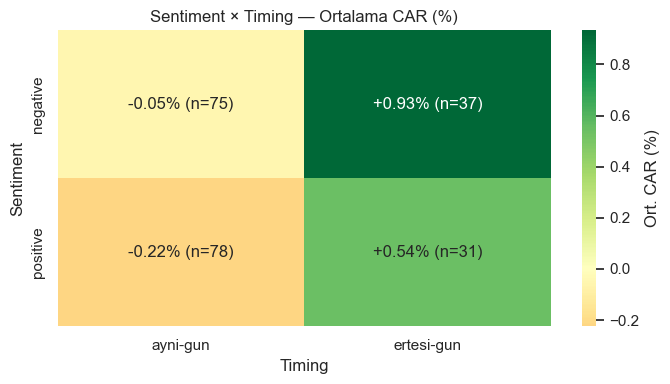

In [9]:
# 2x2 heatmap (ortalama CAR %)
pivot_mean = df.assign(car_pct=df["car"] * 100).pivot_table(
    index="sentiment_label", columns="timing", values="car_pct", aggfunc="mean"
)
pivot_n = df.pivot_table(
    index="sentiment_label", columns="timing", values="car", aggfunc="count"
)

annot = pivot_mean.copy().astype(str)
for r in pivot_mean.index:
    for c in pivot_mean.columns:
        annot.loc[r, c] = f"{pivot_mean.loc[r, c]:+.2f}% (n={int(pivot_n.loc[r, c])})"

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_mean, annot=annot, fmt="", cmap="RdYlGn", center=0,
            cbar_kws={"label": "Ort. CAR (%)"}, ax=ax)
ax.set_title("Sentiment × Timing — Ortalama CAR (%)")
ax.set_xlabel("Timing")
ax.set_ylabel("Sentiment")
plt.tight_layout()
plt.show()


In [10]:
# Anahtar test: pozitif × ertesi-gun alt-grubu, digerlerine kiyasla
key = df[(df["sentiment_label"] == "positive") & (df["timing"] == "ertesi-gun")]["car"].dropna()
rest = df[~((df["sentiment_label"] == "positive") & (df["timing"] == "ertesi-gun"))]["car"].dropna()

print(f"Pozitif x Ertesi-gun (key):  n={len(key)}, ort CAR = {key.mean()*100:+.3f}%, std = {key.std()*100:.3f}%")
print(f"Diger 3 hucre        :      n={len(rest)}, ort CAR = {rest.mean()*100:+.3f}%, std = {rest.std()*100:.3f}%")
print()
welch = stats.ttest_ind(key, rest, equal_var=False)
print(f"Welch t-test (key vs rest): t={welch.statistic:.3f}, p={welch.pvalue:.4f}")

# Tek-ornek t: key alt-grubu CAR=0 hipotezine karsi
one = stats.ttest_1samp(key, 0.0)
print(f"Tek-ornek t (key vs 0):     t={one.statistic:.3f}, p={one.pvalue:.4f}")

# Sign test: key alt-grubu pozitif oran
n_pos = (key > 0).sum()
sign = stats.binomtest(n_pos, len(key), p=0.5, alternative="two-sided")
print(f"Sign test (key, pozitif oran {n_pos}/{len(key)}={n_pos/len(key):.2%}): p={sign.pvalue:.4f}")


Pozitif x Ertesi-gun (key):  n=31, ort CAR = +0.543%, std = 2.278%
Diger 3 hucre        :      n=190, ort CAR = +0.068%, std = 1.765%

Welch t-test (key vs rest): t=1.108, p=0.2751
Tek-ornek t (key vs 0):     t=1.328, p=0.1942
Sign test (key, pozitif oran 21/31=67.74%): p=0.0708


## 4. Hisse Bazinda Sentiment Etkisi

Her hisse icin sentiment label x ortalama CAR.

In [11]:
per_ticker = df.groupby(["ticker", "sentiment_label"])["car"].agg(["count", "mean"]).reset_index()
per_ticker["mean_pct"] = per_ticker["mean"] * 100
pivot = per_ticker.pivot(index="ticker", columns="sentiment_label", values="mean_pct")
pivot_n = per_ticker.pivot(index="ticker", columns="sentiment_label", values="count")

print("Ortalama CAR (%) - Ticker x Sentiment (parantez: n):")
disp = pivot.copy().astype(str)
for r in pivot.index:
    for c in pivot.columns:
        v = pivot.loc[r, c]
        n = pivot_n.loc[r, c]
        if pd.isna(v):
            disp.loc[r, c] = "-"
        else:
            disp.loc[r, c] = f"{v:+.2f}% (n={int(n)})"
print(disp.to_string())


Ortalama CAR (%) - Ticker x Sentiment (parantez: n):
sentiment_label       negative       positive
ticker                                       
ASELS             +0.79% (n=7)  +0.22% (n=12)
EREGL            +0.26% (n=12)  +0.26% (n=10)
GARAN            +0.33% (n=59)  -0.56% (n=52)
KCHOL            -0.01% (n=23)  +0.99% (n=18)
THYAO            +0.22% (n=11)  +0.32% (n=17)


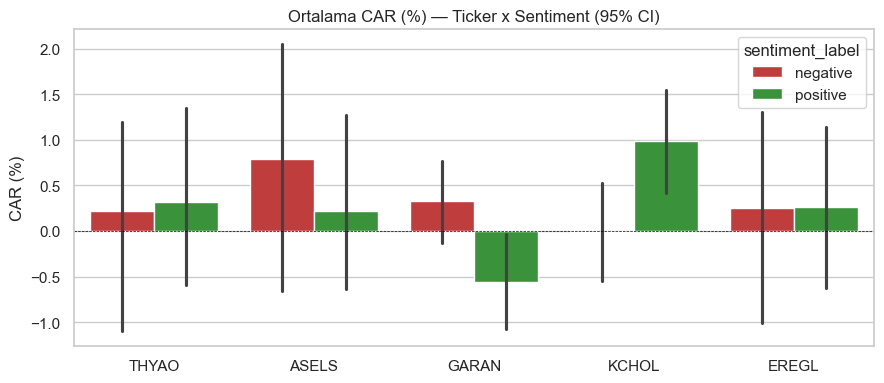

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = df.assign(car_pct=df["car"] * 100)
sns.barplot(data=plot_df, x="ticker", y="car_pct", hue="sentiment_label",
            order=list(TICKERS), hue_order=["negative", "positive"],
            palette={"negative": "tab:red", "positive": "tab:green"},
            errorbar=("ci", 95), ax=ax)
ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
ax.set_title("Ortalama CAR (%) — Ticker x Sentiment (95% CI)")
ax.set_ylabel("CAR (%)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 5. En Yüksek/Düşük Skorlu Bildirim Örnekleri

Modelin en yüksek güvenle pozitif/negatif dediği bildirimleri inceleyip "ne tür bildirim ne skor alıyor" kontrolü.

In [13]:
show_cols = ["ticker", "publish_datetime", "sentiment_label", "sentiment_score", "car", "timing", "subject", "summary"]

print("=== En yuksek skorlu 5 POZITIF (sentiment_score) ===")
top_pos = df[df["sentiment_label"] == "positive"].nlargest(5, "sentiment_score")
for _, r in top_pos.iterrows():
    car_pct = r["car"] * 100
    print(f"  [{r['ticker']}] {pd.Timestamp(r['event_time']):%Y-%m-%d %H:%M}  score={r['sentiment_score']:.3f}  CAR={car_pct:+.2f}%  ({r['timing']})")
    print(f"     {(r['summary'] or r['subject'])[:120]}")

print()
print("=== En yuksek skorlu 5 NEGATIF ===")
top_neg = df[df["sentiment_label"] == "negative"].nlargest(5, "sentiment_score")
for _, r in top_neg.iterrows():
    car_pct = r["car"] * 100
    print(f"  [{r['ticker']}] {pd.Timestamp(r['event_time']):%Y-%m-%d %H:%M}  score={r['sentiment_score']:.3f}  CAR={car_pct:+.2f}%  ({r['timing']})")
    print(f"     {(r['summary'] or r['subject'])[:120]}")


=== En yuksek skorlu 5 POZITIF (sentiment_score) ===
  [GARAN] 2026-01-29 17:05  score=0.992  CAR=-1.68%  (ayni-gun)
     Fitch Ratings kredi derecelendirme notları hakkında

  [GARAN] 2026-04-14 19:13  score=0.992  CAR=-0.74%  (ertesi-gun)
     Fitch Ratings kredi derecelendirme notları hakkında
  [GARAN] 2026-05-18 14:31  score=0.992  CAR=+2.70%  (ayni-gun)
     Fitch Ratings kredi derecelendirme notları hakkında
  [EREGL] 2026-02-24 18:11  score=0.991  CAR=-1.45%  (ayni-gun)
     Fitch Kredi Derecelendirme Notu
  [EREGL] 2026-05-19 19:42  score=0.991  CAR=+0.30%  (ertesi-gun)
     Fitch Kredi Derecelendirme Notu 

=== En yuksek skorlu 5 NEGATIF ===
  [THYAO] 2026-04-09 19:17  score=0.998  CAR=+0.93%  (ertesi-gun)
     Üst Yönetim Değişikliği
  [GARAN] 2026-03-31 19:23  score=0.996  CAR=+1.74%  (ertesi-gun)
     2025 Yılı Kar Dağıtımı Hk.

  [KCHOL] 2026-02-13 18:15  score=0.993  CAR=+0.87%  (ayni-gun)
     Üst Düzey Yönetici Değişikliği
  [GARAN] 2025-12-12 18:17  score=0.988  CAR=+

## 6. Özet Bulgular (run sonrası doldur)

Notebook çalıştığında somut sayılar README'ye taşınacak. Beklenen örüntü:

- **Pozitif × ertesi-gün** alt-grubu en güçlü pozitif CAR — eğer öyleyse: sentiment + timing kombinasyonu, tek başına sentiment veya tek başına timing'den daha iyi bir tahminci.
- Negatif sentiment'in CAR üzerindeki etkisi sınırlı olabilir (KAP bildirimleri genelde nötr-pozitif ton; modelin "negatif" dediği bildirimler çoğunlukla risk açıklamaları, dava süreçleri, vs.).
- Hisse bazında: EREGL'in event_study'deki %82 pozitif yön oranı sentiment ekseninde nasıl ayrışıyor?
